In [36]:
import pandas as pd
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras import backend as K
import pydot
import tensorflow as tf

In [37]:
np.random.seed(10)

In [38]:
from sklearn.datasets import load_breast_cancer
df = load_breast_cancer()

In [39]:
# normalization
X = df.data
Y = df.target

X = ((X-X.mean())/X.std())

In [40]:
# train/test splitting
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state = 42)

In [41]:
import pydot
import graphviz
import os
from IPython.display import display, Image
import tensorflow as tf
from matplotlib import pyplot
from keras import backend
from keras.utils import plot_model
from keras.layers import Dense, Dropout, Flatten, Activation, BatchNormalization

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


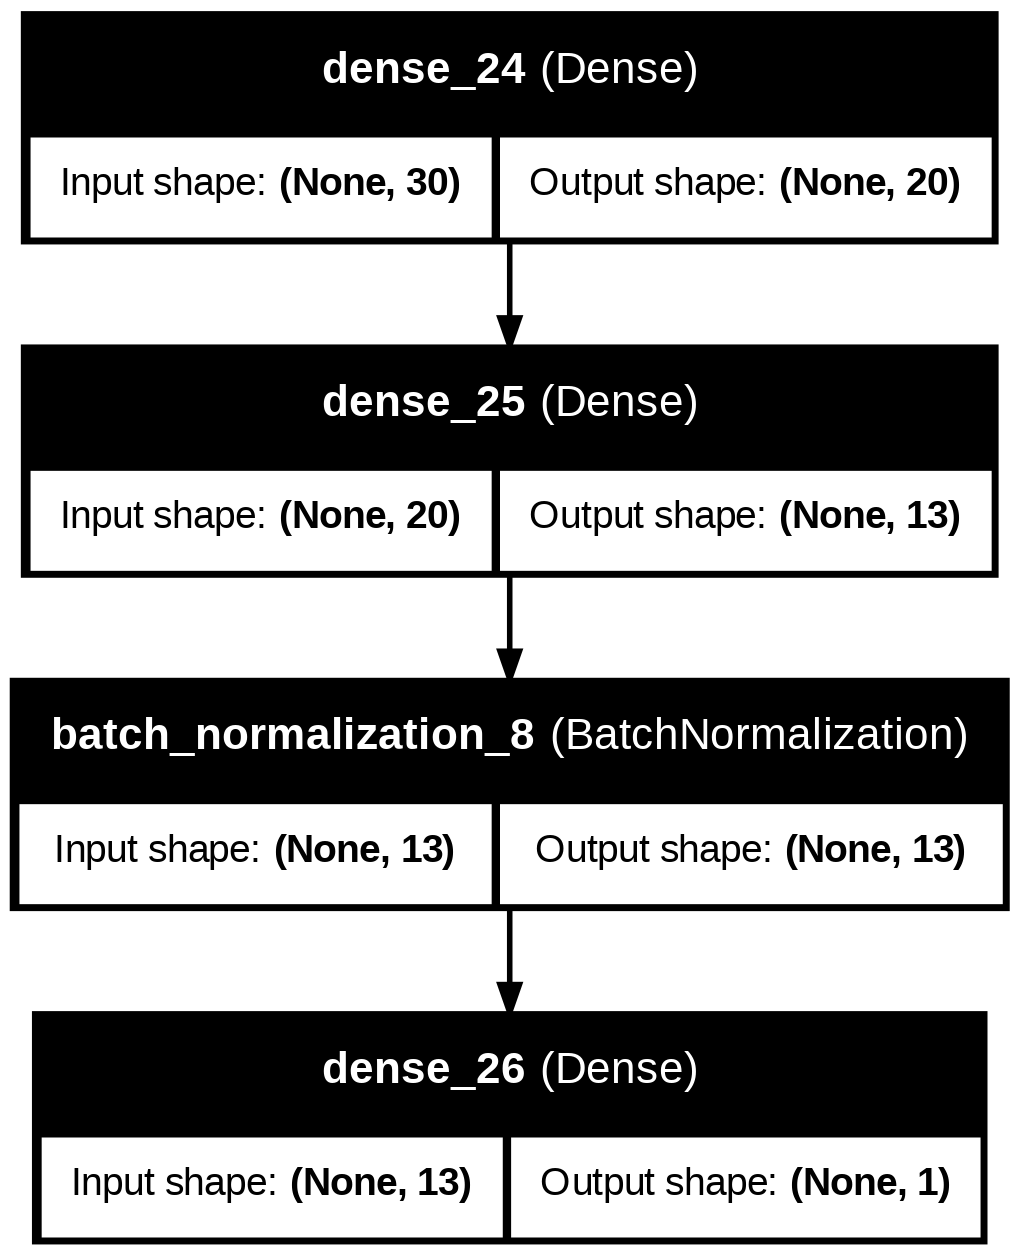

In [42]:
def rmse(y_true, y_pred):
    return tf.math.sqrt(tf.math.reduce_mean(tf.math.square(y_pred - y_true), axis=-1))

nn_model = Sequential()
nn_model.add(Dense(20, input_dim =  30, activation='relu')) # 20 hidden neuroons, 30 input neurons

nn_model.add(Dense(13, activation = 'tanh')) # 13 next hidden neurons,  linked  to 4 neurons on the previous layer
nn_model.add(BatchNormalization())

nn_model.add(Dense(1, activation = 'sigmoid')) # Changed to 1 output unit with sigmoid activation for binary classification

nn_model.compile(loss = 'binary_crossentropy', optimizer  ='adam', metrics = ['accuracy'])

plot_model(nn_model, to_file = 'model_plot.png', show_shapes = True, show_layer_names  = True)
i=Image("model_plot.png")
display(i)

In [47]:
from scipy import stats
history = nn_model.fit(X_train, y_train, epochs = 150, batch_size = 10)

#evaluating
result = nn_model.evaluate(X_test, y_test)

Epoch 1/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9550 - loss: 0.1265
Epoch 2/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9491 - loss: 0.1180
Epoch 3/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9412 - loss: 0.1533
Epoch 4/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9612 - loss: 0.0880
Epoch 5/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9520 - loss: 0.1395
Epoch 6/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9568 - loss: 0.1145
Epoch 7/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9525 - loss: 0.1071
Epoch 8/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9721 - loss: 0.0878
Epoch 9/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9624 - loss: 0.1075
Epoch 10/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9587 - loss: 0.1200
Epoch 11/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9349 - loss: 0.1515
Epoch 12/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accura

In [48]:
print(f'RMSE: {np.mean(rmse(nn_model.predict(X_test),y_test))}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
RMSE: 0.6489273951047484
